**Episodic Semi-Gradient Sarsa + Tile Coding for Discrete Mountain Car**

https://marcinbogdanski.github.io/rl-sketchpad/RL_An_Introduction_2018/1001_Episodic_Semi_Gradient_Sarsa.html


Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from mpl_toolkits.mplot3d import axes3d
import gym
#from helpers_1001 import eval_state_action_space, plot_q_max_3d
#import tiles3           # by Richard Sutton, http://incompleteideas.net/tiles/tiles3.html

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pickle

In [ ]:
# Define the file path within your Google Drive

**Custom_MountainCarEnv + ElectricalDCMotorEnv**

In [ ]:

"""
http://incompleteideas.net/MountainCar/MountainCar1.cp
permalink: https://perma.cc/6Z2N-PFWC
"""
import math
from typing import Optional

import numpy as np

import gym
from gym import spaces
from gym.envs.classic_control import utils
from gym.error import DependencyNotInstalled


class Custom_MountainCarEnv(gym.Env):
    """
    ### Description
    The Mountain Car MDP is a deterministic MDP that consists of a car placed stochastically
    at the bottom of a sinusoidal valley, with the only possible actions being the accelerations
    that can be applied to the car in either direction. The goal of the MDP is to strategically
    accelerate the car to reach the goal state on top of the right hill. There are two versions
    of the mountain car domain in gym: one with discrete actions and one with continuous.
    This version is the one with discrete actions.
    This MDP first appeared in [Andrew Moore's PhD Thesis (1990)](https://www.cl.cam.ac.uk/techreports/UCAM-CL-TR-209.pdf)
    ```
    @TECHREPORT{Moore90efficientmemory-based,
        author = {Andrew William Moore},
        title = {Efficient Memory-based Learning for Robot Control},
        institution = {University of Cambridge},
        year = {1990}
    }
    ```
    ### Observation Space
    The observation is a `ndarray` with shape `(2,)` where the elements correspond to the following:
    | Num | Observation                          | Min  | Max | Unit         |
    |-----|--------------------------------------|------|-----|--------------|
    | 0   | position of the car along the x-axis | -Inf | Inf | position (m) |
    | 1   | velocity of the car                  | -Inf | Inf | position (m) |
    ### Action Space
    There are 3 discrete deterministic actions:
    | Num | Observation             | Value | Unit         |
    |-----|-------------------------|-------|--------------|
    | 0   | Accelerate to the left  | Inf   | position (m) |
    | 1   | Don't accelerate        | Inf   | position (m) |
    | 2   | Accelerate to the right | Inf   | position (m) |
    ### Transition Dynamics:
    Given an action, the mountain car follows the following transition dynamics:
    *velocity<sub>t+1</sub> = velocity<sub>t</sub> + (action - 1) * force - cos(3 * position<sub>t</sub>) * gravity*
    *position<sub>t+1</sub> = position<sub>t</sub> + velocity<sub>t+1</sub>*
    where force = 0.001 and gravity = 0.0025. The collisions at either end are inelastic with the velocity set to 0
    upon collision with the wall. The position is clipped to the range `[-1.2, 0.6]` and
    velocity is clipped to the range `[-0.07, 0.07]`.
    ### Reward:
    The goal is to reach the flag placed on top of the right hill as quickly as possible, as such the agent is
    penalised with a reward of -1 for each timestep.
    ### Starting State
    The position of the car is assigned a uniform random value in *[-0.6 , -0.4]*.
    The starting velocity of the car is always assigned to 0.
    ### Episode End
    The episode ends if either of the following happens:
    1. Termination: The position of the car is greater than or equal to 0.5 (the goal position on top of the right hill)
    2. Truncation: The length of the episode is 200.
    ### Arguments
    ```
    gym.make('MountainCar-v0')
    ```
    ### Version History
    * v0: Initial versions release (1.0.0)
    """

    metadata = {
        "render_modes": ["human", "rgb_array"],
        "render_fps": 30,
    }

    def __init__(self, render_mode: Optional[str] = None, goal_velocity=0):
        self.min_position = -1.2
        self.max_position = 0.6
        self.max_speed = 0.07
        self.goal_position = 0.5
        self.goal_velocity = goal_velocity

        self.tau = 1.0 # seconds between state updates
        self.tau1 =self.tau/20 #.05 # integration time sample
        self.one_over_mass = 0.001 # mass in kg, replaces 1/self.force
        self.gravity = 0.0025

        self.low = np.array([self.min_position, -self.max_speed], dtype=np.float32)
        self.high = np.array([self.max_position, self.max_speed], dtype=np.float32)

        self.render_mode = render_mode

        self.screen_width = 600
        self.screen_height = 400
        self.screen = None
        self.clock = None
        self.isopen = True

        self.action_space = spaces.Discrete(3)
        self.observation_space = spaces.Box(self.low, self.high, dtype=np.float32)

                ### Customization changes ######
        '''add ElectricalDCMotorEnv to the CartPole class
        and assign values to
        Resistor_R, inductor_L, torque_const_Kt and bemf_const_Ke'''
        self.DCMotorModel = ElectricalDCMotorEnv()
        self.DCMotorModel.tau = self.tau1
        self.DCMotorModel.Resistor_R = 1.0
        self.DCMotorModel.inductor_L = 0.1
        self.DCMotorModel.torque_const_Kt = 1.0
        self.DCMotorModel.bemf_const_Ke = 1.0
        self.DCMotorModel.current = 0.0
        self.DCMotorModel.current_error = 0.0
        self.DCMotorModel.current_error_acc = 0.0
        self.DCMotorModel.current_error_prev = 0.0
        ####
        self.wanted_force = 0.0


    def step(self, action: int):
        assert self.action_space.contains( action ), f"{action!r} ({type(action)}) invalid"

        position, velocity = self.state
        wanted_force = (action - 1) # wanted forces in Newton = {-1,0,+1}[N]
        self.wanted_force=wanted_force

        current_ref = wanted_force/self.DCMotorModel.torque_const_Kt

        for t in np.arange(start=0.0, stop=self.tau, step=self.tau1):
          #generates actual force
          actual_force = self.DCMotorModel.step(current_ref = current_ref, x_dot = velocity)
          #actual_force = wanted_force # change for perfect applying force

          # NOTE: if tau=1 and tau1=1 and actual_force=force (no feed thru PID),
          #      then we have the "ideal" mountain car ENV

          #actual force is divded by 0.001 (defult) kg mass
          velocity += (actual_force * self.one_over_mass - self.gravity * math.cos(3 * position))*self.tau1
          if velocity > self.max_speed:
              velocity = self.max_speed
          if velocity < -self.max_speed:
              velocity = -self.max_speed
          position += (velocity)*self.tau1
          if position > self.max_position:
              position = self.max_position
          if position < self.min_position:
              position = self.min_position
          if position == self.min_position and velocity < 0:
              velocity = 0

        terminated = bool(
            position >= self.goal_position #and velocity >= self.goal_velocity
        )
        reward = -1.0

        self.state = (position, velocity)
        if self.render_mode == "human":
            self.render()
        return np.array(self.state, dtype=np.float32), reward, terminated, False ,wanted_force , actual_force

    def reset(
        self,
        *,
        seed: Optional[int] = None,
        options: Optional[dict] = None,
    ):
        super().reset(seed=seed)
        # Note that if you use custom reset bounds, it may lead to out-of-bound
        # state/observations.
        low, high = utils.maybe_parse_reset_bounds(options, -0.6, -0.4)
        self.state = np.array([self.np_random.uniform(low=low, high=high), 0])

        ### zerowise DC motor init. conditions
        self.DCMotorModel.current = 0.0
        self.DCMotorModel.current_error = 0.0
        self.DCMotorModel.current_error_acc = 0.0
        self.DCMotorModel.current_error_prev = 0.0
        self.wanted_force = 0.0

        if self.render_mode == "human":
            self.render()
        return np.array(self.state, dtype=np.float32), {}

    def _height(self, xs):
        return np.sin(3 * xs) * 0.45 + 0.55

    def render(self):
        if self.render_mode is None:
            gym.logger.warn(
                "You are calling render method without specifying any render mode. "
                "You can specify the render_mode at initialization, "
                f'e.g. gym("{self.spec.id}", render_mode="rgb_array")'
            )
            return

        try:
            import pygame
            from pygame import gfxdraw
        except ImportError:
            raise DependencyNotInstalled(
                "pygame is not installed, run `pip install gym[classic_control]`"
            )

        if self.screen is None:
            pygame.init()
            if self.render_mode == "human":
                pygame.display.init()
                self.screen = pygame.display.set_mode(
                    (self.screen_width, self.screen_height)
                )
            else:  # mode in "rgb_array"
                self.screen = pygame.Surface((self.screen_width, self.screen_height))
        if self.clock is None:
            self.clock = pygame.time.Clock()

        world_width = self.max_position - self.min_position
        scale = self.screen_width / world_width
        carwidth = 40
        carheight = 20

        self.surf = pygame.Surface((self.screen_width, self.screen_height))
        self.surf.fill((255, 255, 255))

        pos = self.state[0]

        xs = np.linspace(self.min_position, self.max_position, 100)
        ys = self._height(xs)
        xys = list(zip((xs - self.min_position) * scale, ys * scale))

        pygame.draw.aalines(self.surf, points=xys, closed=False, color=(0, 0, 0))

        clearance = 10

        l, r, t, b = -carwidth / 2, carwidth / 2, carheight, 0
        coords = []
        for c in [(l, b), (l, t), (r, t), (r, b)]:
            c = pygame.math.Vector2(c).rotate_rad(math.cos(3 * pos))
            coords.append(
                (
                    c[0] + (pos - self.min_position) * scale,
                    c[1] + clearance + self._height(pos) * scale,
                )
            )

        gfxdraw.aapolygon(self.surf, coords, (0, 0, 0))
        gfxdraw.filled_polygon(self.surf, coords, (0, 0, 0))

        for c in [(carwidth / 4, 0), (-carwidth / 4, 0)]:
            c = pygame.math.Vector2(c).rotate_rad(math.cos(3 * pos))
            wheel = (
                int(c[0] + (pos - self.min_position) * scale),
                int(c[1] + clearance + self._height(pos) * scale),
            )

            gfxdraw.aacircle(
                self.surf, wheel[0], wheel[1], int(carheight / 2.5), (128, 128, 128)
            )
            gfxdraw.filled_circle(
                self.surf, wheel[0], wheel[1], int(carheight / 2.5), (128, 128, 128)
            )

        flagx = int((self.goal_position - self.min_position) * scale)
        flagy1 = int(self._height(self.goal_position) * scale)
        flagy2 = flagy1 + 50
        gfxdraw.vline(self.surf, flagx, flagy1, flagy2, (0, 0, 0))

        gfxdraw.aapolygon(
            self.surf,
            [(flagx, flagy2), (flagx, flagy2 - 10), (flagx + 25, flagy2 - 5)],
            (204, 204, 0),
        )
        gfxdraw.filled_polygon(
            self.surf,
            [(flagx, flagy2), (flagx, flagy2 - 10), (flagx + 25, flagy2 - 5)],
            (204, 204, 0),
        )

        self.surf = pygame.transform.flip(self.surf, False, True)
        self.screen.blit(self.surf, (0, 0))
        if self.render_mode == "human":
            pygame.event.pump()
            self.clock.tick(self.metadata["render_fps"])
            pygame.display.flip()

        elif self.render_mode == "rgb_array":
            return np.transpose(
                np.array(pygame.surfarray.pixels3d(self.screen)), axes=(1, 0, 2)
            )

    def get_keys_to_action(self):
        # Control with left and right arrow keys.
        return {(): 1, (276,): 0, (275,): 2, (275, 276): 1}

    def close(self):
        if self.screen is not None:
            import pygame

            pygame.display.quit()
            pygame.quit()
            self.isopen = False

In [ ]:
class ElectricalDCMotorEnv():

      def __init__(self):
        self.Resistor_R = 1.0
        self.inductor_L = 0.1
        self.torque_const_Kt = 1.0
        self.bemf_const_Ke = 1.0
        self.tau = 0.02
        #
        self.Kp = 1.0
        self.Ki = 1.0
        self.Kd = 1e-2
        self.aL=10.0**(-3) #Low pass parameter
        self.aH = 10.0**2 #High pass parameter
        #
        self.current = 0.0
        self.current_error = 0.0
        self.current_error_acc = 0.0
        self.current_error_prev = 0.0
        self.voltage_input = 0.0
        self.xdot = 0.0
        self.PID_Discretization = "Simple" #"Backward""Simple", " "Bilinear" , "Forward" "Simple"

      def step(self, current_ref, x_dot):
        aL = self.aL
        aH = self.aH
        self.current_error = current_ref-self.current
        delta_error = self.current_error-self.current_error_prev

        if self.PID_Discretization == "Simple":
          self.current_error_acc += self.current_error*self.tau
          HP_delta_error = delta_error

        elif self.PID_Discretization == "Backward":
          self.current_error_acc = (self.current_error_acc+(self.current_error)*self.tau)/(1+aL*self.tau) #Low Pass
          HP_delta_error = (self.current_error + aH*delta_error)/(1+aL*self.tau)#High Pass

        elif self.PID_Discretization == "Bilinear":
          error_avg = (self.current_error+self.current_error_prev)/2
          self.current_error_acc =  ((1-aL*self.tau/2)*self.current_error_acc + error_avg*self.tau)/(1+aL*self.tau/2)#Low Pass
          HP_delta_error =  ((1-aL*self.tau/2)*self.current_error + aH*delta_error)/(1+aL*self.tau/2)#High Pass

        else:
          self.current_error_acc = (1-aL*self.tau)*self.current_error_acc+(self.current_error_prev)*self.tau #Low Pass
          HP_delta_error = (1-aH*self.tau)*self.current_error + aH*delta_error #High Pass

        P = self.Kp*self.current_error
        #I = self.Ki*self.current_error_acc*self.tau
        I = self.Ki*self.current_error_acc
        #D = self.Kd*HP_delta_error/self.tau
        D = self.Kd*HP_delta_error/self.tau
        voltage_BEMF = x_dot*self.bemf_const_Ke
        voltage_input = P+I+D+voltage_BEMF
        voltage_input=np.clip(voltage_input,-10,10)


        self.current_error_prev = 0+self.current_error
        self.current += self.tau*(voltage_input-voltage_BEMF-self.current*self.Resistor_R)/self.inductor_L
        self.current = np.clip(self.current,-2,2)
        self.voltage_input = voltage_input
        self.xdot = x_dot
        F=self.torque_const_Kt*self.current

        return F # return applied Force

Episodic Semi-Gradient Sarsa

In [ ]:
plotting_rewards=[]
avg_reward_list = []

save_observation = []
save_u1 = []
save_pid_u1 = []
save_ctrl_voltage = []

In [ ]:
def policy(st, q_hat, eps):
    if np.random.rand() > eps:
        act_space = range(env.action_space.n)
        q_values = [q_hat.eval(st,a) for a in act_space]
        return argmax_rand(q_values)
    else:
        return np.random.choice(env.action_space.n)

In [ ]:
def ep_semi_grad_sarsa(env, episodes, gamma, epsilon_start, epsilon_end, epsilon_decay,
                       q_hat, q_hat_target, callback=None, trace=None, train_mode=True):
    """Episodic Semi-Gradient Sarsa

    Params:
        env - environment
        ep - number of episodes to run
        gamma - discount factor [0..1]
        epsilon_start, epsilon_end, epsilon_decay - epsilon-greedy params:
          epsilon = epsilon_end + (epsilon_start-epsilon_end)*epsilon_decay**(episode no. n)
        q_hat      - function approximator, already initialised, with methods:
                     eval(state, action) -> float
                     train(state, target) -> None
    """

    # skip weight intialization,
    best_score = -300
    lr = None
    #for e_ in range(ep):
    episode_n = 0
    best_episode = 0
    print(f"learning rate: {q_hat._lr:E}")
    while(episode_n<episodes):
        S, infor = env.reset()
        epsilon = epsilon_end + (epsilon_start-epsilon_end)*epsilon_decay**episode_n
        if episode_n==int(episodes*0.5):
            q_hat._weights = q_hat_target._weights+0
            print(f"Reinitiate weight from Best Episode:{best_episode}; Best Score:{best_score}")
            q_hat._lr=q_hat_target._lr*1e-1
            print(f"learning rate: {q_hat._lr:E}")
        #if episode_n==int(episodes*0.9):
        #    q_hat._weights = q_hat_target._weights+0
        #    print(f"Reinitiate weight from Best Episode:{best_episode}; Best Score:{best_score}")
        #    q_hat._lr=q_hat_target._lr*1e-1
        #    print(f"learning rate: {q_hat._lr:E}")
        A = policy(S, q_hat, epsilon)
        score = 0
        #for t_ in range(200): #10**100
        t_=0
        while(t_<200) and (episode_n<episodes):
            infor = env.step(A)
            S_= infor[0]
            R = infor[1]
            done = infor[2]
            u=infor[4]
            u_after_pid=infor[5]
            ##
            if episode_n == episodes-1:
              save_observation.append(S_)
              save_u1.append(u)
              save_pid_u1.append(u_after_pid)
              save_ctrl_voltage.append(env.DCMotorModel.voltage_input)
            #end if
            score += R
            if done or ((t_+1)%200==0):
                  plotting_rewards.append(score)
                  avg_reward = np.mean(plotting_rewards[-20:])
                  print(f"EPISODE: {episode_n} - FINAL SCORE: {avg_reward} ") # Print the final score
                  avg_reward_list.append(avg_reward)
                  if best_score < score:
                      q_hat_target._weights = q_hat._weights+0
                      best_score = score
                      best_episode = episode_n
                      print(f"Best Episode:{best_episode}; Best Score:{best_score}")
                  #end if
                  episode_n+=1
                  score = 0
            #end if
            lr = None
            if done:
                q_hat.train(S, A, R, lr)
                break
            #end if
            A_ = policy(S_, q_hat, epsilon)
            target = R + gamma * q_hat.eval(S_, A_)

            if train_mode: #### add boolian cond. for train mode
              q_hat.train(S, A, target ,lr)
            #end if

            S, A = S_, A_

            if callback is not None:
                callback(episode_n, t_, q_hat, trace)
            #end if
            t_+=1
        #end while
    #end while
    print(f"Best Episode:{best_episode}; Best Score:{best_score}")
#end def

Tile Coding

In [ ]:
class TileCodingFuncApprox():
    def __init__(self, st_low, st_high, nb_actions, learn_rate, num_tilings, init_val):
        """
        Params:
            st_low      - state space low boundry in all dim, e.g. [-1.2, -0.07] for mountain car
            st_high     - state space high boundry in all dimensions
            nb_actions  - number of possible actions
            learn_rate  - step size, will be adjusted for nb_tilings automatically
            num_tilings - tiling layers - should be power of 2 and at least 4*len(st_low)
            init_val    - initial state-action values
        """
        assert len(st_low) == len(st_high)
        self._n_dim = len(st_low)
        self._lr = learn_rate / num_tilings
        self._num_tilings = num_tilings
        self._scales = self._num_tilings / (st_high - st_low)

        # e.g. 8 tilings, 2d space, 3 actions
        # nb_total_tiles = (8+1) * (8+1) * 8 * 3
        nb_total_tiles = (num_tilings+1)**self._n_dim * num_tilings * nb_actions

        self._iht = IHT(nb_total_tiles)
        self._weights = np.zeros(nb_total_tiles) + init_val / num_tilings

    def eval(self, state, action):
        #assert len(state) == self._n_dim
        #assert np.isscalar(action)
        scaled_state = np.multiply(self._scales, state)  # scale state to map to tiles correctly
        active_tiles = tiles(                     # find active tiles
            self._iht, self._num_tilings,
            scaled_state, [action])
        return np.sum(self._weights[active_tiles])       # pick correct weights and sum up

    def train(self, state, action, target, lr=None):
        #assert len(state) == self._n_dim
        #assert np.isscalar(action)
        #assert np.isscalar(target)
        if lr is None:
            lr=self._lr
        scaled_state = np.multiply(self._scales, state)  # scale state to map to tiles correctly
        active_tiles = tiles(                     # find active tiles
            self._iht, self._num_tilings,
            scaled_state, [action])
        value = np.sum(self._weights[active_tiles])      # q-value for state-action pair
        delta = lr * (target - value)              # grad is [0,1,0,0,..]
        self._weights[active_tiles] += delta             # ..so we pick active weights instead

In [ ]:
"""
Tile Coding Software version 3.0beta
by Rich Sutton
based on a program created by Steph Schaeffer and others
External documentation and recommendations on the use of this code is available in the
reinforcement learning textbook by Sutton and Barto, and on the web.
These need to be understood before this code is.

This software is for Python 3 or more.

This is an implementation of grid-style tile codings, based originally on
the UNH CMAC code (see http://www.ece.unh.edu/robots/cmac.htm), but by now highly changed.
Here we provide a function, "tiles", that maps floating and integer
variables to a list of tiles, and a second function "tiles-wrap" that does the same while
wrapping some floats to provided widths (the lower wrap value is always 0).

The float variables will be gridded at unit intervals, so generalization
will be by approximately 1 in each direction, and any scaling will have
to be done externally before calling tiles.

Num-tilings should be a power of 2, e.g., 16. To make the offsetting work properly, it should
also be greater than or equal to four times the number of floats.

The first argument is either an index hash table of a given size (created by (make-iht size)),
an integer "size" (range of the indices from 0), or nil (for testing, indicating that the tile
coordinates are to be returned without being converted to indices).

Documentation : http://incompleteideas.net/tiles/tiles3.html
"""

basehash = hash

class IHT:
    "Structure to handle collisions"
    def __init__(self, sizeval):
        self.size = sizeval
        self.overfullCount = 0
        self.dictionary = {}

    def __str__(self):
        "Prepares a string for printing whenever this object is printed"
        return "Collision table:" + \
               " size:" + str(self.size) + \
               " overfullCount:" + str(self.overfullCount) + \
               " dictionary:" + str(len(self.dictionary)) + " items"

    def count (self):
        return len(self.dictionary)

    def fullp (self):
        return len(self.dictionary) >= self.size

    def getindex (self, obj, readonly=False):
        d = self.dictionary
        if obj in d: return d[obj]
        elif readonly: return None
        size = self.size
        count = self.count()
        if count >= size:
            if self.overfullCount==0: print('IHT full, starting to allow collisions')
            self.overfullCount += 1
            return basehash(obj) % self.size
        else:
            d[obj] = count
            return count

def hashcoords(coordinates, m, readonly=False):
    if type(m)==IHT: return m.getindex(tuple(coordinates), readonly)
    if type(m)==int: return basehash(tuple(coordinates)) % m
    if m==None: return coordinates

from math import floor, log
from itertools import zip_longest

    # find active tiles
    #tiles(self._iht, self._num_tilings,scaled_state, [action])
def tiles (ihtORsize, numtilings, floats, ints=[], readonly=False):
    """returns num-tilings tile indices corresponding to the floats and ints"""
    qfloats = [floor(f*numtilings) for f in floats]
    Tiles = []
    for tiling in range(numtilings):
        tilingX2 = tiling*2
        coords = [tiling]
        b = tiling
        for q in qfloats:
            coords.append( (q + b) // numtilings )
            b += tilingX2
        coords.extend(ints)
        Tiles.append(hashcoords(coords, ihtORsize, readonly))
    return Tiles

def tileswrap (ihtORsize, numtilings, floats, wrawidths, ints=[], readonly=False):
    """returns num-tilings tile indices corresponding to the floats and ints, wrapping some floats"""
    qfloats = [floor(f*numtilings) for f in floats]
    Tiles = []
    for tiling in range(numtilings):
        tilingX2 = tiling*2
        coords = [tiling]
        b = tiling
        for q, width in zip_longest(qfloats, wrapwidths):
            c = (q + b%numtilings) // numtilings
            coords.append(c%width if width else c)
            b += tilingX2
        coords.extend(ints)
        Tiles.append(hashcoords(coords, ihtORsize, readonly))
    return Tiles

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

def plot_q_max_3d(q_arr, env, color='#1f77b4', alpha=1.,
                  title='', labels=['x','y','z'], axis=None):
    """Plot 3D wireframe

    Params:
        q_arr     - 2d array with dim: [state_x, state_y]
        env       - environment with members:
                      st_low - state space low boundry e.g. [-1.2, -0.07]
                      st_high - state space high boundry
        color     - plot color
        alpha     - plot transparency
        labels    - string array [label_x, label_y, label_z], len=3, empty str to omit
        axis      - axis to plot to, if None create new figure
    """
    q_max = -1 * np.max(q_arr, axis=-1)  # calc max and inverse

    x_min, x_max = env.low[0], env.high[0]
    y_min, y_max = env.low[1], env.high[1]
    x_space = np.linspace(x_min, x_max, num=q_max.shape[0])
    y_space = np.linspace(y_min, y_max, num=q_max.shape[1])
    Y, X = np.meshgrid(y_space, x_space)

    if axis is None:
        fig = plt.figure()
        axis = fig.add_subplot(111, projection='3d')

    axis.plot_wireframe(X, Y, q_max, color=color, alpha=alpha)
    axis.set_xlabel(labels[0])
    axis.set_ylabel(labels[1])
    axis.set_zlabel(labels[2])
    axis.set_xticks([x_min, x_max])
    axis.set_yticks([y_min, y_max])
    axis.set_title(title)

    axis.view_init(40, -70)



def eval_state_action_space(q_hat, env, split=[32,32]):
    """Evaluate 2d Q-function on area and return as 3d array

    Params:
        q_hat     - function approximator with method: q_hat.eval(state, action) -> float
        env       - environment with members:
                      st_low - state space low boundry e.g. [-1.2, -0.07]
                      st_high - state space high boundry
                      act_space - action space, e.g. [0, 1, 2]
        split     - number of data points in each dimensions, e.g. [20, 20]
    """
    x_min, x_max = env.low[0], env.high[0]
    y_min, y_max = env.low[1], env.high[1]
    x_split, y_split = split

    q_arr = np.zeros([x_split, y_split, env.action_space.n])
    act_space = range(env.action_space.n)
    for pi, pos in enumerate(np.linspace(x_min, x_max, x_split)):
        for vi, vel in enumerate(np.linspace(y_min, y_max, y_split)):
            for act in act_space:
                q_arr[pi, vi, act] = q_hat.eval(state=[pos, vel], action=act)

    return q_arr

Helper functions

In [ ]:
def argmax_rand(arr):
    # break ties randomly, np.argmax() always picks first max
    return np.random.choice(np.flatnonzero(arr == np.max(arr)))

In [ ]:
def callback(episode, tstep, model, trace):
    """Called from gradient_MC after every episode.

    Params:
        episode [int] - episode number
        tstep [int]   - timestep within episode
        model [obj]   - function approximator
        trace [list]  - list to write results to"""
    episodes = [1, 12, 104, 1000, 9000]
    if episode in episodes and tstep == 0:
        q_arr = eval_state_action_space(q_hat, env)
        trace.append(q_arr)

Solve Mountain Car

In [ ]:
env =  Custom_MountainCarEnv()

In [ ]:
print(env.action_space.n)

3


In [ ]:
q_hat = TileCodingFuncApprox(env.low, env.high, env.action_space.n,
                             learn_rate=0.5, num_tilings=8, init_val=0)

q_hat_target = TileCodingFuncApprox(env.low, env.high, env.action_space.n,
                             learn_rate=0.5, num_tilings=8, init_val=1)

In [ ]:
print(q_hat._weights.shape)

(1944,)


In [ ]:
path = '/content/drive/MyDrive/Colab Notebooks/codes/Fixed PID Constants/save_data/Disc_Moun_Car/'

In [ ]:
ep_semi_grad_sarsa(env, episodes=2000, gamma=1.00, epsilon_start=0.99, epsilon_end=1e-3, epsilon_decay=0.9,
                   q_hat=q_hat, q_hat_target=q_hat_target)

learning rate: 6.250000E-02
EPISODE: 0 - FINAL SCORE: -200.0 
Best Episode:0; Best Score:-200.0
EPISODE: 1 - FINAL SCORE: -200.0 
EPISODE: 2 - FINAL SCORE: -200.0 
EPISODE: 3 - FINAL SCORE: -200.0 
EPISODE: 4 - FINAL SCORE: -200.0 
EPISODE: 5 - FINAL SCORE: -200.0 
EPISODE: 6 - FINAL SCORE: -200.0 
EPISODE: 7 - FINAL SCORE: -200.0 
EPISODE: 8 - FINAL SCORE: -200.0 
EPISODE: 9 - FINAL SCORE: -200.0 
EPISODE: 10 - FINAL SCORE: -200.0 
EPISODE: 11 - FINAL SCORE: -200.0 
EPISODE: 12 - FINAL SCORE: -200.0 
EPISODE: 13 - FINAL SCORE: -200.0 
EPISODE: 14 - FINAL SCORE: -200.0 
EPISODE: 15 - FINAL SCORE: -198.4375 
Best Episode:15; Best Score:-175.0
EPISODE: 16 - FINAL SCORE: -198.52941176470588 
EPISODE: 17 - FINAL SCORE: -198.61111111111111 
EPISODE: 18 - FINAL SCORE: -198.68421052631578 
EPISODE: 19 - FINAL SCORE: -198.75 
EPISODE: 20 - FINAL SCORE: -198.75 
EPISODE: 21 - FINAL SCORE: -198.75 
EPISODE: 22 - FINAL SCORE: -198.75 
EPISODE: 23 - FINAL SCORE: -198.75 
EPISODE: 24 - FINAL SCORE:

In [ ]:
# Test
# Test
#save_observation_temp = []
#save_u1_temp = []
#save_pid_u1_temp = []
#save_ctrl_voltage_temp = []
plotting_rewards_test = []
total_episodes_test = 100
best_score = -300
epsilon = 1e-3

In [ ]:
print('Test')
#for e_ in range(ep):
episode_n = 0
best_episode = 0
while(episode_n<total_episodes_test):
  S, infor = env.reset()
  A = policy(S, q_hat, epsilon)
  save_observation_temp = [S]
  save_u1_temp = [0.0]
  save_pid_u1_temp = [0.0]
  save_ctrl_voltage_temp = []
  score = 0
  #for t_ in range(200): #10**100
  t_=0
  while(t_<200) and (episode_n<total_episodes_test):
    infor = env.step(A)
    S_= infor[0]
    R = infor[1]
    done = infor[2]
    u=infor[4]
    u_after_pid=infor[5]
    ##
    save_observation_temp.append(S_)
    save_u1_temp.append(u)
    save_pid_u1_temp.append(u_after_pid)
    save_ctrl_voltage_temp.append(env.DCMotorModel.voltage_input)
    score += R
    if done or ((t_+1)%200==0):
      plotting_rewards_test.append(score)
      print(f"EPISODE: {episode_n} - FINAL SCORE: {score} ") # Print the final score
      if best_score < score:
        best_score = score
        best_episode = episode_n
        save_observation = list(save_observation_temp)
        save_u1 = list(save_u1_temp)
        save_pid_u1 = list(save_pid_u1_temp)
        save_ctrl_voltage_temp.append(env.DCMotorModel.voltage_input)
        save_ctrl_voltage = list(save_ctrl_voltage_temp)
        print(f"Best Episode:{best_episode}; Best Score:{best_score}")
      #end if
      episode_n+=1
      score = 0
    #end if
    if done:
      break
    #end if
    A_ = policy(S_, q_hat, epsilon)
    S, A = S_, A_
    t_+=1
  #end while
#end while
print(f"Best Episode:{best_episode}; Best Score:{best_score}")

Test
EPISODE: 0 - FINAL SCORE: -107.0 
Best Episode:0; Best Score:-107.0
EPISODE: 1 - FINAL SCORE: -107.0 
EPISODE: 2 - FINAL SCORE: -85.0 
Best Episode:2; Best Score:-85.0
EPISODE: 3 - FINAL SCORE: -88.0 
EPISODE: 4 - FINAL SCORE: -107.0 
EPISODE: 5 - FINAL SCORE: -96.0 
EPISODE: 6 - FINAL SCORE: -95.0 
EPISODE: 7 - FINAL SCORE: -92.0 
EPISODE: 8 - FINAL SCORE: -107.0 
EPISODE: 9 - FINAL SCORE: -93.0 
EPISODE: 10 - FINAL SCORE: -107.0 
EPISODE: 11 - FINAL SCORE: -88.0 
EPISODE: 12 - FINAL SCORE: -119.0 
EPISODE: 13 - FINAL SCORE: -107.0 
EPISODE: 14 - FINAL SCORE: -114.0 
EPISODE: 15 - FINAL SCORE: -86.0 
EPISODE: 16 - FINAL SCORE: -107.0 
EPISODE: 17 - FINAL SCORE: -122.0 
EPISODE: 18 - FINAL SCORE: -107.0 
EPISODE: 19 - FINAL SCORE: -91.0 
EPISODE: 20 - FINAL SCORE: -107.0 
EPISODE: 21 - FINAL SCORE: -93.0 
EPISODE: 22 - FINAL SCORE: -84.0 
Best Episode:22; Best Score:-84.0
EPISODE: 23 - FINAL SCORE: -107.0 
EPISODE: 24 - FINAL SCORE: -107.0 
EPISODE: 25 - FINAL SCORE: -140.0 
EPISO

In [ ]:
save_observation_temp = None
save_u1_temp = None
save_pid_u1_temp = None
save_ctrl_voltage_temp = None

In [ ]:
# Create a dictionary of variables you want to save

variables_to_save = {
    'plotting_rewards': plotting_rewards,
    'avg_reward_list': avg_reward_list,
    'save_observation': save_observation,
    'save_u1': save_u1,
    'save_pid_u1': save_pid_u1,
    'save_ctrl_voltage': save_ctrl_voltage,
    'q_hat': q_hat,
    'plotting_rewards_test':plotting_rewards_test
}

In [ ]:
with open(path+'Disc_Moun_Car.pkl', 'wb') as f:
    pickle.dump(variables_to_save, f)
print(f"All variables saved to {path+'Disc_Moun_Car.pkl'}")

All variables saved to /content/drive/MyDrive/Colab Notebooks/codes/Fixed PID Constants/save_data/Disc_Moun_Car/Disc_Moun_Car.pkl


In [ ]:
path = '/content/drive/MyDrive/Colab Notebooks/codes/Fixed PID Constants/save_data/Disc_Moun_Car/'

In [ ]:
# Open the file in read-binary mode and load the dictionary
with open(path+'Disc_Moun_Car.pkl', 'rb') as f:
    loaded_variables = pickle.load(f)

# Access the loaded variables
plotting_rewards = loaded_variables['plotting_rewards']
avg_reward_list = loaded_variables['avg_reward_list']
save_observation = loaded_variables['save_observation']
save_u1 = loaded_variables['save_u1']
save_pid_u1 = loaded_variables['save_pid_u1']
save_ctrl_voltage = loaded_variables['save_ctrl_voltage']
q_hat = loaded_variables['q_hat']
plotting_rewards_test = loaded_variables['plotting_rewards_test']

In [ ]:
plt.rc('text.latex', preamble=r'\usepackage{amsmath,amssymb,amsfonts}')
#plt.rcParams["text.usetex"]=False
#plt.rcParams["font.family"] = "sans-serif"
#plt.rcParams["font.family"] = "serif"
#plt.rcParams['mathtext.fontset'] = 'cm'
#plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

In [ ]:
def unnorm_to_norm(x):
  y = (x-low_bound_reward_list)/(up_bound_reward_list-low_bound_reward_list)
  return y

In [ ]:
def norm_to_unnorm(y):
  x=y*(up_bound_reward_list-low_bound_reward_list)+low_bound_reward_list
  return x

In [ ]:
low_bound_reward_list = -200
up_bound_reward_list = 0
print("low_bound_reward_list=",low_bound_reward_list)
print("up_bound_reward_list=",up_bound_reward_list)
norm_reward_list = np.array(avg_reward_list)
norm_reward_list = unnorm_to_norm(norm_reward_list)

low_bound_reward_list= -200
up_bound_reward_list= 0


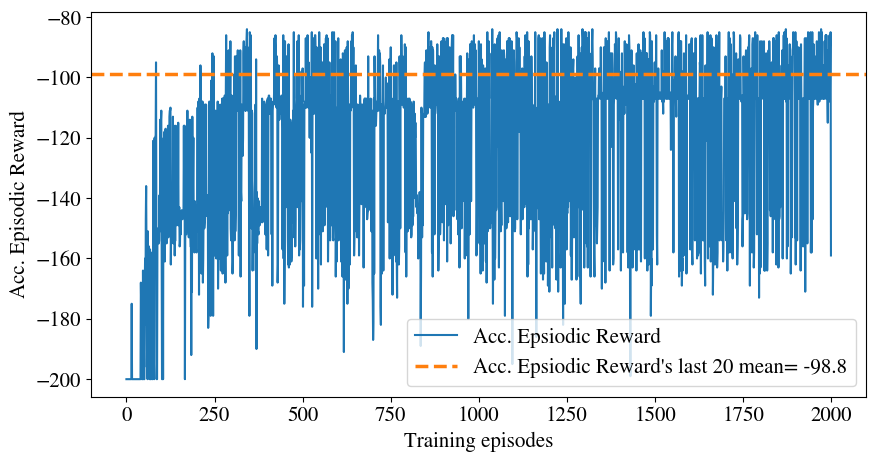

In [ ]:
import matplotlib.pyplot as plt

font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
#plt.plot(plotting_rewards)
plt.plot(plotting_rewards, label = "Acc. Epsiodic Reward",color="C0",linewidth = 1.5)
plt.axhline(y=np.array(plotting_rewards)[-20:-1].mean(), linestyle='--',
            label = "Acc. Epsiodic Reward's last 20 mean= "+f"{np.array(plotting_rewards)[-20:-1].mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel('Training episodes',fontsize=15)
plt.ylabel('Acc. Episodic Reward',fontsize=15)
#plt.rc('axes', labelsize=30)

#plt.grid()
plt.legend()
#plt.title('Discrete_mountain_car',fontsize=20)
plt.show()

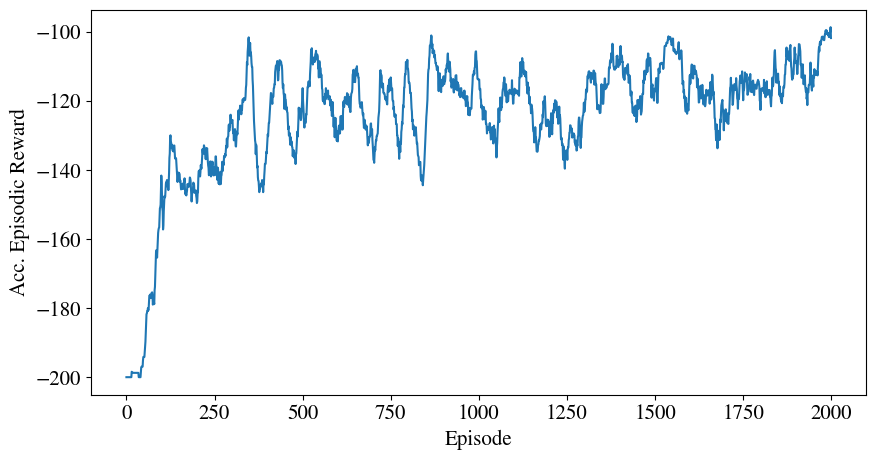

In [ ]:
# Plotting graph
# Episodes versus Acc. Rewards
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(avg_reward_list, label = "Acc. Episodic Reward",color="C0",linewidth = 1.5)
#plt.axhline(y=np.array(avg_reward_list)[-20:-1].mean(), linestyle='--',
#            label = "Acc. Epsiodic Reward's last 20 mean= "+f"{np.array(avg_reward_list)[-20:-1].mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel("Episode")
plt.ylabel("Acc. Episodic Reward")
#plt.grid()
#plt.legend()
#plt.savefig("my_graph.pdf", format='pdf', bbox_inches='tight')
#plt.savefig('my_graph.eps', format='eps')
plt.show()

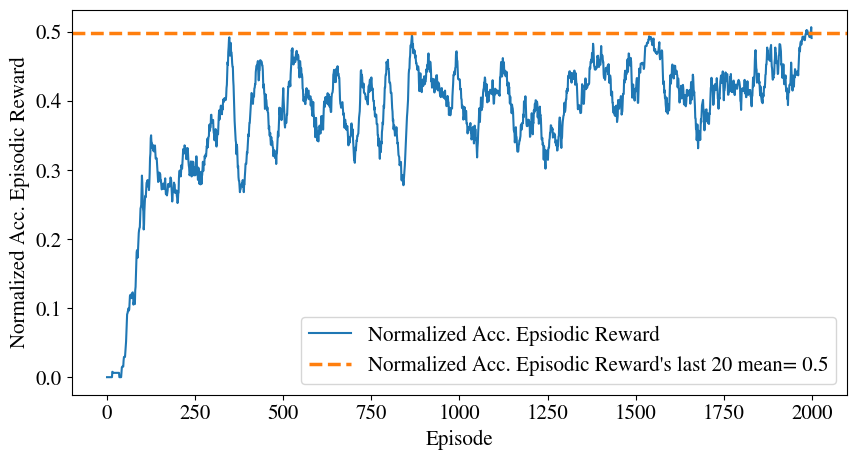

In [ ]:
# Episodes versus Avg. Rewards
#norm_reward_list = np.array(avg_reward_list)
#norm_reward_list = (norm_reward_list/abs(norm_reward_list.min())+1)*100
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(norm_reward_list, label = "Normalized Acc. Epsiodic Reward",color="C0",linewidth = 1.5)
plt.axhline(y=norm_reward_list[-20:-1].mean(), linestyle='--',
            label = "Normalized Acc. Episodic Reward's last 20 mean= "+f"{norm_reward_list[-20:-1].mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel("Episode")
plt.ylabel("Normalized Acc. Episodic Reward")
#plt.grid()
plt.legend()
plt.show()

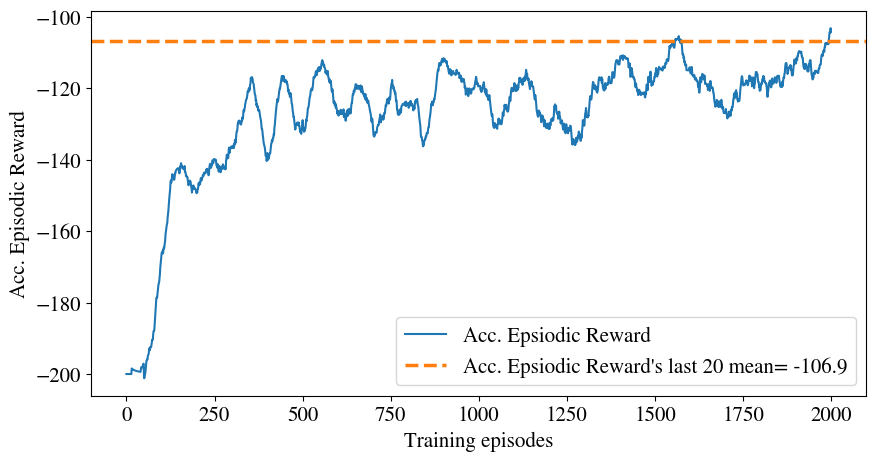

In [ ]:
N=50
# Compute the moving average of the last 50 numbers
moving_average = []
for i, n in enumerate(plotting_rewards):
    if i < N:
        # If there are not enough previous elements,
        # append the average of all available elements
        avg = sum(plotting_rewards[:i+1]) / (i+1)
    else:
        # Otherwise, compute the average of the previous 5 elements
        avg = sum(plotting_rewards[i-N:i+1]) / N
    moving_average.append(avg)

# Plot the moving average
#plt.plot(moving_average)
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
#plt.plot(plotting_rewards)
plt.plot(moving_average, label = "Acc. Epsiodic Reward",color="C0",linewidth = 1.5)
plt.axhline(y=np.array(moving_average)[-20:-1].mean(), linestyle='--',
            label = "Acc. Epsiodic Reward's last 20 mean= "+f"{np.array(moving_average)[-20:-1].mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel('Training episodes',fontsize=15)
plt.ylabel('Acc. Episodic Reward',fontsize=15)

#plt.grid()
plt.legend()
#plt.title('Discrete_mountain_car-Avg',fontsize=20)
plt.show()

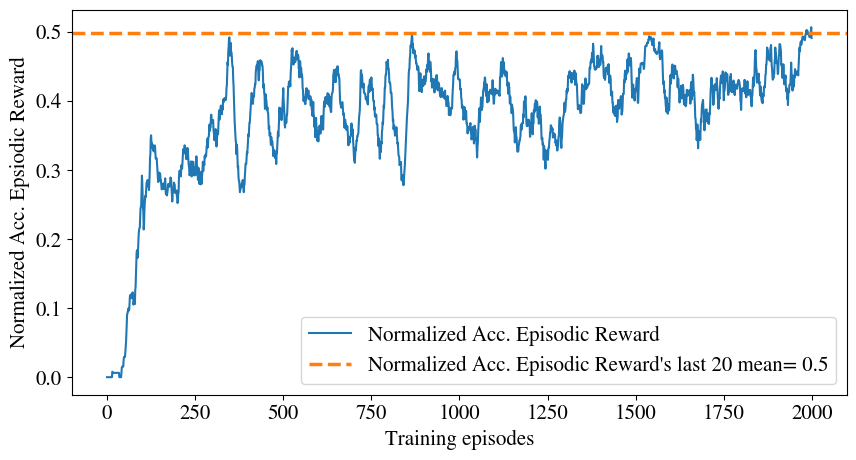

In [ ]:
# Episodes versus Avg. Rewards
#norm_reward_list = np.array(moving_average)
#norm_reward_list = (norm_reward_list/abs(norm_reward_list.min())+1)*100
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(norm_reward_list, label = "Normalized Acc. Episodic Reward",color="C0",linewidth = 1.5)
plt.axhline(y=norm_reward_list[-20:-1].mean(), linestyle='--',
            label = "Normalized Acc. Episodic Reward's last 20 mean= "+f"{norm_reward_list[-20:-1].mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel("Training episodes")
plt.ylabel("Normalized Acc. Epsiodic Reward")
#plt.grid()
plt.legend()
plt.show()

In [ ]:
N=50
# Compute the moving average of the last 50 numbers
moving_average = []
for i, n in enumerate(avg_reward_list):
    if i < N:
        # If there are not enough previous elements,
        # append the average of all available elements
        avg = sum(plotting_rewards[:i+1]) / (i+1)
    else:
        # Otherwise, compute the average of the previous 5 elements
        avg = sum(avg_reward_list[i-N:i+1]) / N
    moving_average.append(avg)

plt.axes:  <function axes at 0x7a7b79203ec0>


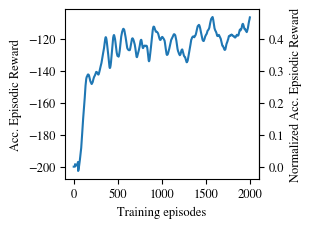

In [ ]:
# Plot the moving average
#plt.plot(moving_average)
font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(2.5)
f.set_figheight(2.2)
#plt.plot(plotting_rewards)
#fig, ax = plt.subplots()#(layout='constrained')
plt.plot(moving_average, label = "Acc. Epsiodic Reward",color="C0",linewidth = 1.5)
#plt.axhline(y=np.array(moving_average)[-20:-1].mean(), linestyle='--',
#            label = "Acc. Epsiodic Reward's last 20 mean= "+f"{np.array(moving_average)[-20:-1].mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel('Training episodes')
plt.ylabel('Acc. Episodic Reward')
print("plt.axes: ", plt.axes)
#plt.grid()
#plt.legend()
#plt.title('Discrete_mountain_car-Avg',fontsize=20)
ax = plt.gca()
secax_y = ax.secondary_yaxis(
    'right', functions=(unnorm_to_norm, norm_to_unnorm))
secax_y.set_ylabel("Normalized Acc. Epsiodic Reward")
plt.show()

In [ ]:
print(np.array(plotting_rewards).min())

-200.0


In [ ]:
moving_average=unnorm_to_norm(np.array(moving_average))

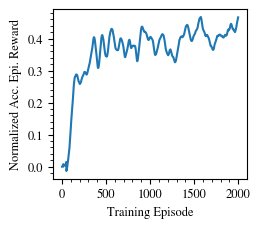

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Episodes versus Avg. Rewards
#norm_reward_list = np.array(moving_average)
#min_norm_reward_list = np.array(plotting_rewards).min()
#max_norm_reward_list= 0
#norm_reward_list = (norm_reward_list-min_norm_reward_list)/(max_norm_reward_list-min_norm_reward_list)
font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(2.5)
f.set_figheight(2.2)
plt.plot(moving_average, label = "Normalized Acc. Episodic Reward",color="C0",linewidth = 1.5)
#plt.axhline(y=norm_reward_list[-20:-1].mean(), linestyle='--',
#            label = "Normalized Acc. Episodic Reward's last 20 mean= "+f"{norm_reward_list[-20:-1].mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel("Training Episode")
plt.ylabel("Normalized Acc. Epi. Reward")
#plt.grid()
#plt.legend()
plt.minorticks_on()
plt.savefig(path+"Disc_Mount_Car_Acc_Reward_vs_Episode.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
print("Normalized Acc. Epsiodic Reward's last 20 mean=")
print(norm_reward_list[-20:-1].mean())

Normalized Acc. Epsiodic Reward's last 20 mean=
0.49735526315789463


In [ ]:
# Test Histogram
norm_ep_reward_list_test = np.array(plotting_rewards_test)
#norm_ep_reward_list_test = (norm_ep_reward_list_test-min_norm_reward_list)/(max_norm_reward_list-min_norm_reward_list)
norm_ep_reward_list_test = unnorm_to_norm(norm_ep_reward_list_test)
print(norm_ep_reward_list_test.max())
print(norm_ep_reward_list_test.min())
min_bin = np.floor(norm_ep_reward_list_test.min()*100)/100

0.58
0.3


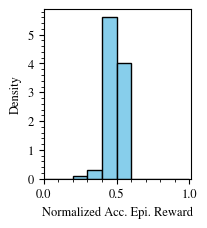

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(1.9)
f.set_figheight(2.2)
data_rewards = np.array(norm_ep_reward_list_test)
density_True = True

plt.hist(data_rewards, bins=np.arange(0,1.01,0.1), density=density_True ,color='skyblue', edgecolor='black')
plt.xlabel('Normalized Acc. Epi. Reward')
ylabel='Density'if density_True else 'Frequency'
plt.ylabel(ylabel)
#plt.xticks(np.arange(0.2,1.01,0.1))
plt.minorticks_on()
plt.xlim((0.0,1.01))
plt.savefig(path+"Disc_Mount_Car_Acc_Reward_vs_Episode_Test_Hist.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
print("Test Normalized Acc Episodic Reward's Results:")
print(f"Unnormalized: max={norm_to_unnorm(data_rewards).max():.3f} ,mean={norm_to_unnorm(data_rewards).mean():.3f}, std={norm_to_unnorm(data_rewards).std():.3f}")
print(f"Normalized:   max={data_rewards.max():.3e} ,mean={data_rewards.mean():.3e}, std={data_rewards.std():.3e}")

Test Normalized Acc Episodic Reward's Results:
Unnormalized: max=-84.000 ,mean=-101.610, std=10.726
Normalized:   max=5.800e-01 ,mean=4.920e-01, std=5.363e-02


In [ ]:
dt=env.tau

/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1984: PyparsingDeprecationWarning: 'setName' deprecated - use 'set_name'
  val.setName(key)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1987: PyparsingDeprecationWarning: 'setParseA

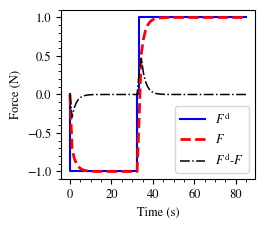

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
time_position_u1= np.linspace(start = 0, stop = len(save_u1)*dt,num=len(save_u1) )
time_position__pid_u1= np.linspace(start = 0, stop = len(save_u1)*dt,num=len(save_u1) )

e_ry=np.array(save_u1)-np.array(save_pid_u1)
mean_std=f'(mean,std)=({e_ry.mean():.2e}, {e_ry.std():.2e})'

font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(2.5)
f.set_figheight(2.2)

plt.step(time_position_u1, save_u1 ,label = r"$F^\mathrm{d}$",color="blue",linewidth = 1.5)
plt.plot(time_position__pid_u1, np.array(save_pid_u1), '--',label = r"$F$",color="red",linewidth = 2)
plt.plot(time_position_u1, e_ry,'-.',label = r"$F^\mathrm{d}$-$F$",color="black",linewidth = 1.1)

plt.xlabel("Time (s)")
plt.ylabel("Force (N)")
plt.minorticks_on()

#plt.grid()
plt.legend()
plt.savefig(path+"Disc_Mount_Car_Force_vs_Time.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
print(mean_std)

(mean,std)=(8.71e-03, 8.16e-02)


In [ ]:
print(f"mae={np.abs(e_ry).mean():.3e}")

mae=2.613e-02


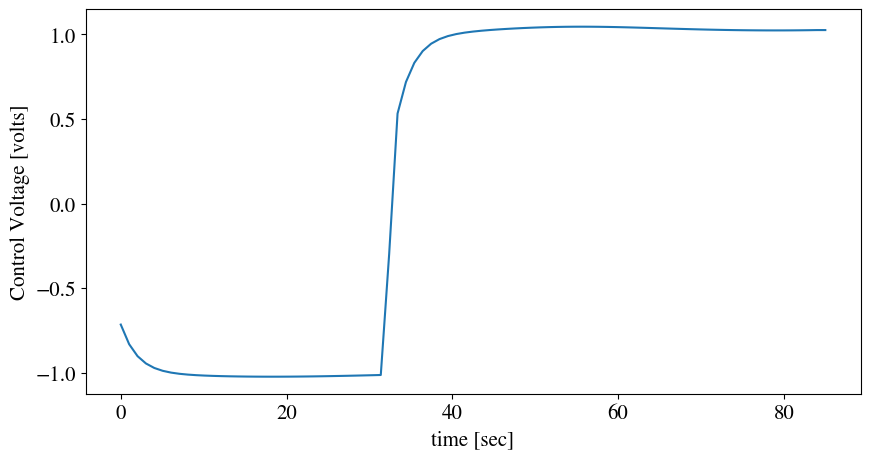

In [ ]:
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.plot(time_position_u1, save_ctrl_voltage)
plt.xlabel("time [sec]")
plt.ylabel("Control Voltage [volts]")
#plt.grid()
plt.show()

In [ ]:
import math

position_print = []
velocity_print = []


for observ in save_observation:
  for index,value in enumerate(observ):
    if index == 0:
      position_print.append(value)

    if index == 1:
      velocity_print.append(value)


In [ ]:
print(len(position_print))

85


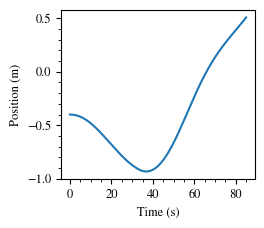

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_position_print = np.linspace(start = 0, stop = len(position_print)*dt,num=len(position_print))##############################################
#time_position , position
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_position_print[-1] , 300)

spl = make_interp_spline(time_position_print, position_print, k=3)  # type: BSpline
power_smooth = spl(xnew)

font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(2.5)
f.set_figheight(2.2)

plt.plot(xnew, power_smooth)
plt.ylabel('Position (m)')
plt.xlabel('Time (s)')
plt.minorticks_on()

#plt.grid()
#plt.legend()
#plt.title('POSITION')
plt.savefig(path+"Disc_Mount_Position_vs_Time.pdf", format='pdf', bbox_inches='tight')
plt.show()

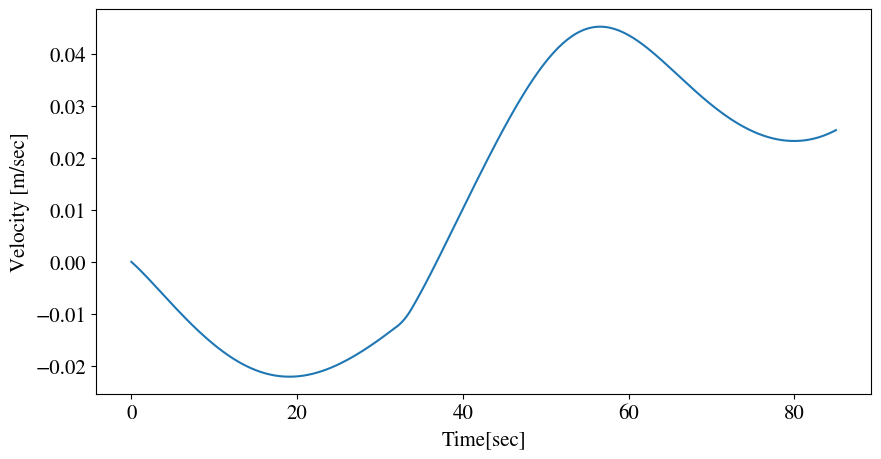

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_velocity_print = np.linspace(start = 0, stop = len(velocity_print)* dt,num=len(velocity_print))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_velocity_print[-1] , 300)

spl = make_interp_spline(time_velocity_print, velocity_print, k=3)  # type: BSpline
power_smooth = spl(xnew)

font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.plot(xnew, power_smooth)
plt.ylabel('Velocity [m/sec]')
plt.xlabel('Time[sec]')
#plt.grid()
#plt.title('VELOCITY')
plt.show()

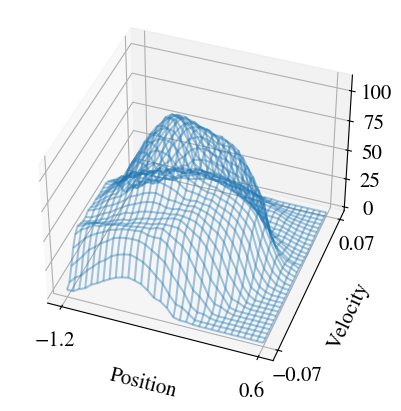

In [ ]:
q_arr = eval_state_action_space(q_hat, env)
plot_q_max_3d(q_arr, env, labels=['Position', 'Velocity', ''], alpha=0.4)

In [ ]:
import random

In [ ]:
i=random.randint(0, len(save_observation))
print("i=",i)

i= 79


In [ ]:
#i=71

In [ ]:
state_i = save_observation[i]
print("state=",state_i,"\n")
learn_rate=0.3
num_tilings=8
st_low, st_high, nb_actions = env.low, env.high, env.action_space.n
print("st_low=",st_low,"\n",
      "st_high=",st_high,"\n"
      "nb_actions=", nb_actions)
n_dim = len(st_low)
print("n_dim=",n_dim,"\n")
lr = learn_rate / num_tilings
print("lr=",lr,"\n")
scales = num_tilings / (st_high - st_low)
print("scales=",scales,"\n")
# e.g. 8 tilings, 2d space, 3 actions
        # nb_total_tiles = (8+1) * (8+1) * 8 * 3
nb_total_tiles = (num_tilings+1)**n_dim * num_tilings * nb_actions
print("nb_total_tiles=",nb_total_tiles,"\n")

iht = IHT(nb_total_tiles)

state= [0.38654432 0.02328117] 

st_low= [-1.2  -0.07] 
 st_high= [0.6  0.07] 
nb_actions= 3
n_dim= 2 

lr= 0.0375 

scales= [ 4.444444 57.142857] 

nb_total_tiles= 1944 



In [ ]:
scaled_state_i = np.multiply(scales, state_i)
print(scaled_state_i)

[1.7179747 1.3303523]


In [ ]:
active_tiles = tiles(                     # find active tiles
            iht, num_tilings,
            scaled_state_i, [0])
print(active_tiles)

[0, 1, 2, 3, 4, 5, 6, 7]


In [ ]:
init_val=1

In [ ]:
for i in range(len(save_observation)):
  state = save_observation[i]
  scaled_state = np.multiply(scales, state)
  for a in range(nb_actions):
    active_tiles = tiles(iht, num_tilings, scaled_state, [a])
    print(f"i={i},a={a}, active_tiles=", active_tiles)

i=0,a=0, active_tiles= [8, 9, 10, 11, 12, 13, 14, 15]
i=0,a=1, active_tiles= [16, 17, 18, 19, 20, 21, 22, 23]
i=0,a=2, active_tiles= [24, 25, 26, 27, 28, 29, 30, 31]
i=1,a=0, active_tiles= [32, 9, 10, 11, 12, 13, 14, 15]
i=1,a=1, active_tiles= [33, 17, 18, 19, 20, 21, 22, 23]
i=1,a=2, active_tiles= [34, 25, 26, 27, 28, 29, 30, 31]
i=2,a=0, active_tiles= [32, 9, 10, 35, 12, 13, 14, 15]
i=2,a=1, active_tiles= [33, 17, 18, 36, 20, 21, 22, 23]
i=2,a=2, active_tiles= [34, 25, 26, 37, 28, 29, 30, 31]
i=3,a=0, active_tiles= [32, 9, 10, 35, 12, 13, 38, 15]
i=3,a=1, active_tiles= [33, 17, 18, 36, 20, 21, 39, 23]
i=3,a=2, active_tiles= [34, 25, 26, 37, 28, 29, 40, 31]
i=4,a=0, active_tiles= [32, 41, 10, 35, 12, 13, 38, 15]
i=4,a=1, active_tiles= [33, 42, 18, 36, 20, 21, 39, 23]
i=4,a=2, active_tiles= [34, 43, 26, 37, 28, 29, 40, 31]
i=5,a=0, active_tiles= [32, 41, 10, 35, 12, 13, 38, 15]
i=5,a=1, active_tiles= [33, 42, 18, 36, 20, 21, 39, 23]
i=5,a=2, active_tiles= [34, 43, 26, 37, 28, 29, 40, 3

In [ ]:
weights = np.zeros(nb_total_tiles) + init_val / num_tilings
print(weights)

[0.125 0.125 0.125 ... 0.125 0.125 0.125]


In [ ]:
state_tiles = np.zeros(nb_total_tiles,dtype=int)
state_tiles[active_tiles]=1
print(state_tiles)

[0 0 0 ... 0 0 0]
